# Diffusion Policy 

- 用一个最小但完整的实现串起 **Diffusion Policy** 训练与采样流程
- 解释为何它能处理多峰动作分布（multi-modal action distribution）
- 说明强化学习中两类常见困难：
  1. 策略分布密度难以显式计算（无法直接写出 $\log \pi(a|s)$）
  2. 策略梯度难以直接计算（环境不可导、采样过程离散/随机）

---

## 1. 问题定义

我们希望学习条件策略 $\pi_\theta(a|s)$，其中：
- $s$：状态（state）
- $a$：动作（action）

Diffusion Policy 不直接输出一次动作，而是学习一个“从噪声逐步去噪到动作”的条件生成过程。

设训练样本动作为 $a_0$，扩散步为 $t \in \{0,\dots,T-1\}$，前向加噪：

$$
q(a_t|a_0)=\mathcal N\left(a_t;\sqrt{\bar\alpha_t}a_0,(1-\bar\alpha_t)I\right),\quad
\bar\alpha_t=\prod_{i=1}^t \alpha_i,\; \alpha_i=1-\beta_i
$$

训练时随机采样 $t$ 并构造：

$$
a_t=\sqrt{\bar\alpha_t}a_0+\sqrt{1-\bar\alpha_t}\,\epsilon,\quad \epsilon\sim\mathcal N(0,I)
$$

模型学习预测噪声（或直接预测 $a_0$），最常见目标：

$$
\mathcal L(\theta)=\mathbb E_{(s,a_0),t,\epsilon}\left[\|\epsilon-\epsilon_\theta(a_t,t,s)\|^2\right]
$$

采样时从 $a_T\sim\mathcal N(0,I)$ 开始迭代反推到 $a_0$，得到最终动作。

### 工具类说明 1：时间步编码与参数平滑（精确公式）

这一段代码定义两个常用工具：
- `SinusoidalPosEmb`：把离散时间步 $t$ 映射到连续向量，便于网络感知“当前噪声强度”。
- `EMA`：对模型参数做指数滑动平均，减小训练抖动。

设嵌入维度为 $d$，半维为 $h=d/2$，实现里频率写成：

$$
\omega_i = \exp\!\left(-\frac{\log(10000)}{h-1}i\right)=10000^{-\frac{i}{h-1}},\quad i=0,1,\dots,h-1
$$

对应时间编码（与代码 `torch.cat([sin, cos])` 一致）：

$$
\mathrm{PE}(t)=\big[\sin(t\omega_0),\dots,\sin(t\omega_{h-1}),\cos(t\omega_0),\dots,\cos(t\omega_{h-1})\big]
$$

其中最低频对应较大尺度变化，最高频对应细粒度变化，使模型同时感知“粗时间位置”和“细时间位置”。

EMA 更新公式：

$$
\theta_{ema} \leftarrow \beta\,\theta_{ema} + (1-\beta)\,\theta
$$

其中 $\beta\in(0,1)$，通常取接近 1（如 0.99、0.995、0.999）。

In [ ]:
import math
import time
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

class SinusoidalPosEmb(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, x):
        device = x.device
        half_dim = self.dim // 2
        emb = math.log(10000) / (half_dim - 1)
        # torch.arange(half_dim) -> [0, 1, 2, ..., half_dim-1]
        # torch.exp(torch.arange(half_dim) * -emb) -> [1, exp(-emb), exp(-2*emb), ..., exp(-(half_dim-1)*emb)]
        # [1, exp(-log(10000)/(half_dim-1)), exp(-2*log(10000)/(half_dim-1)), ..., exp(-(half_dim-1)*log(10000)/(half_dim-1))]
        # [1, exp((half_dim-1)^(-1))/10000^1, exp((half_dim-1)^(-1))/10000^2, ..., exp((half_dim-1)^(-1))/10000^(half_dim-1)]
        emb = torch.exp(torch.arange(half_dim, device=device) * -emb)
        # t*[1, exp((half_dim-1)^(-1))/10000^1, exp((half_dim-1)^(-1))/10000^2, ..., exp((half_dim-1)^(-1))/10000^(half_dim-1)]
        emb = x[:, None] * emb[None, :]
        emb = torch.cat((emb.sin(), emb.cos()), dim=-1)
        return emb

class EMA():
    '''
        empirical moving average
    '''
    def __init__(self, beta):
        super().__init__()
        self.beta = beta

    def update_model_average(self, ma_model, current_model):
        for current_params, ma_params in zip(current_model.parameters(), ma_model.parameters()):
            old_weight, up_weight = ma_params.data, current_params.data
            ma_params.data = self.update_average(old_weight, up_weight)

    def update_average(self, old, new):
        if old is None:
            return new
        return old * self.beta + (1 - self.beta) * new

In [2]:
# ---------------------- 运行工具与通用函数 ---------------------- #

def set_seed(seed=42):
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

class Silent:
    def update(self, info=None):
        return None

    def close(self):
        return None

class Progress:
    def __init__(self, total):
        self.total = total
        self.start = time.time()

    def update(self, info=None):
        if info is None:
            return
        t = info.get('t', None)
        if t is not None and (t % max(self.total // 10, 1) == 0 or t == 0):
            elapsed = time.time() - self.start
            print(f"sampling t={t:4d}/{self.total-1}, elapsed={elapsed:.2f}s")

    def close(self):
        pass

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
set_seed(42)
print('device:', DEVICE)

device: cuda


### 工具类说明 2：随机性控制与采样进度

这一段用于工程可复现与调试：
- `set_seed`：固定随机种子，尽量保证结果可复现。
- `Progress/Silent`：在反向采样中显示或关闭进度。

扩散采样链本质是马尔可夫链：

$$
a_T \sim \mathcal N(0, I),\quad a_{t-1} \sim p_\theta(a_{t-1}|a_t,s)
$$

因为链路含随机噪声，固定 seed 可以让实验更可对比。

In [3]:
#-----------------------------------------------------------------------------#
#---------------------------------- losses -----------------------------------#
#-----------------------------------------------------------------------------#

class WeightedLoss(nn.Module):

    def __init__(self):
        super().__init__()

    def forward(self, pred, targ, weights=1.0):
        '''
            pred, targ : tensor [ batch_size x action_dim ]
        '''
        loss = self._loss(pred, targ)
        weighted_loss = (loss * weights).mean()
        return weighted_loss

class WeightedL1(WeightedLoss):

    def _loss(self, pred, targ):
        return torch.abs(pred - targ)

class WeightedL2(WeightedLoss):

    def _loss(self, pred, targ):
        return F.mse_loss(pred, targ, reduction='none')


Losses = {
    'l1': WeightedL1,
    'l2': WeightedL2,
}

## 2. 前向扩散与反向采样（DDPM / DDIM）

### 2.1 前向扩散（训练时构造噪声样本）

前向过程不需要神经网络，直接由闭式公式采样：

$$
a_t = \sqrt{\bar\alpha_t}a_0 + \sqrt{1-\bar\alpha_t}\epsilon
$$

这让我们可以在任意 $t$ 上训练，而无需逐步模拟 $0\to t$ 的所有中间步。

### 2.2 DDPM 反向采样（随机）

当模型预测噪声 $\epsilon_\theta(a_t,t,s)$ 时，可先重建 $\hat a_0$：

$$
\hat a_0 = \frac{a_t-\sqrt{1-\bar\alpha_t}\,\epsilon_\theta(a_t,t,s)}{\sqrt{\bar\alpha_t}}
$$

再通过后验均值与方差采样 $a_{t-1}$。代码中用到的 `posterior_mean_coef1/2` 与 `posterior_log_variance_clipped` 就是这个公式的向量化实现。

### 2.3 DDIM 反向采样（可确定性）

DDIM 用

$$
\sigma_t = \eta\sqrt{\frac{1-\bar\alpha_{t-1}}{1-\bar\alpha_t}\left(1-\frac{\bar\alpha_t}{\bar\alpha_{t-1}}\right)}
$$

控制随机性：
- $\eta=0$：确定性采样（快、稳定）
- $\eta>0$：保留随机探索

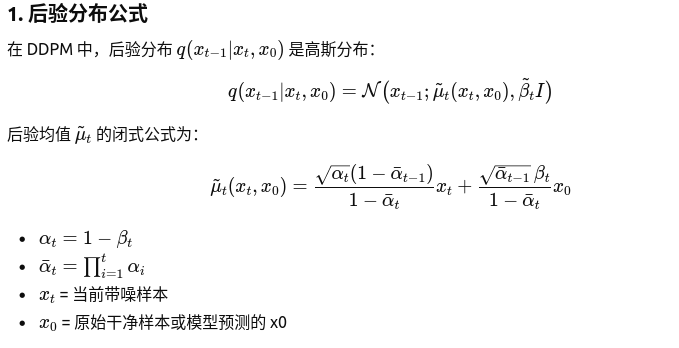
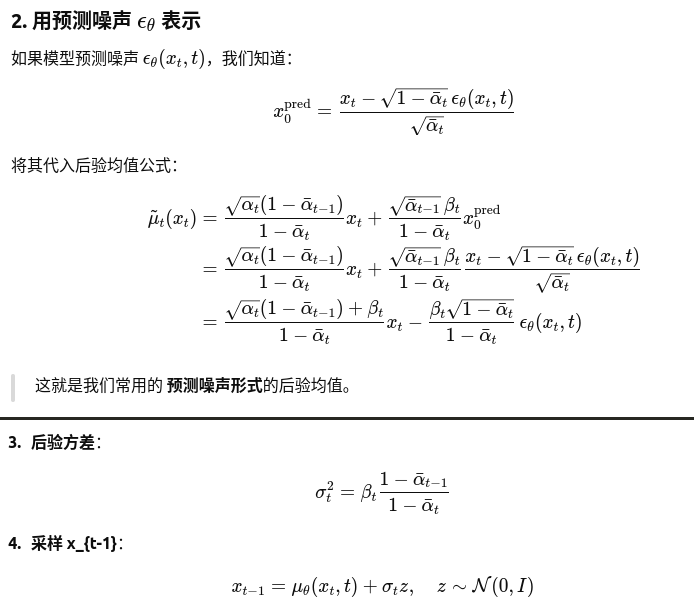

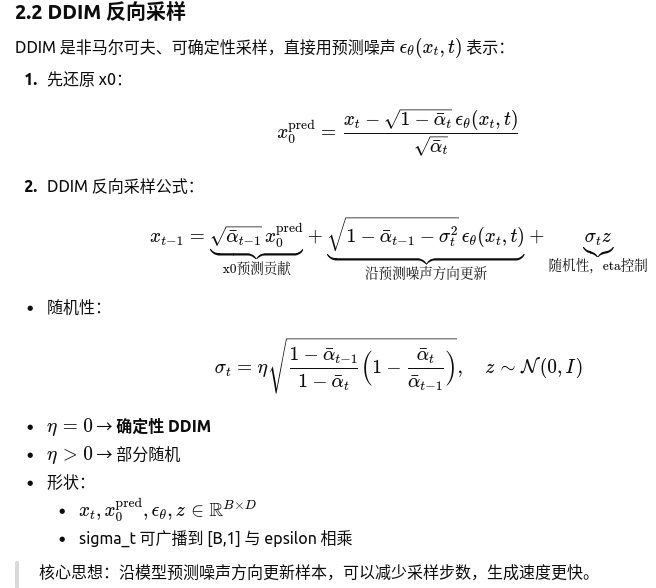

## 3. 代码结构说明（本笔记最小实现）

- `MLP`：噪声预测网络 $\epsilon_\theta(a_t,t,s)$
- `Diffusion`：
  - `forward_diffusion`：按闭式公式加噪
  - `loss`：随机采样时间步并计算噪声回归损失
  - `reverse_diffusion`：DDPM 采样
- `DDIMDiffusion`：继承 `Diffusion`，只替换反向采样公式

训练流程（行为克隆视角）
1. 从离线数据集中取 $(s, a_0)$
2. 随机采样时间步 $t$
3. 得到 $a_t$，让模型预测噪声
4. 最小化预测噪声与真实噪声误差

推理流程
1. 给定状态 $s$
2. 从高斯噪声初始化动作
3. 迭代去噪得到最终动作 $a_0$

### 工具类说明 3：噪声预测网络（MLP）

这里的 `MLP` 实现的是条件噪声预测器 $\epsilon_\theta(a_t,t,s)$：
- 输入：当前噪声动作 $a_t$、时间步嵌入 $t$、状态 $s$
- 输出：预测噪声 $\hat\epsilon$

训练阶段常用目标（噪声回归）：

$$
\min_\theta\; \mathbb E\left[\|\epsilon-\epsilon_\theta(a_t,t,s)\|_2^2\right]
$$

这等价于让模型学习“在给定状态和噪声强度下，当前动作里哪些部分是噪声”。

In [4]:
class MLP(nn.Module):
    """
    MLP Model,噪声预测模型
    """
    def __init__(self,
                 state_dim,
                 action_dim,
                 device,
                 t_dim=16):
        super(MLP, self).__init__()
        self.device = device

        self.time_mlp = nn.Sequential(
            SinusoidalPosEmb(t_dim),
            nn.Linear(t_dim, t_dim * 2),
            nn.Mish(),
            nn.Linear(t_dim * 2, t_dim),
        )
        
        input_dim = state_dim + action_dim + t_dim
        self.mid_layer = nn.Sequential(nn.Linear(input_dim, 256),
                                       nn.Mish(),
                                       nn.Linear(256, 256),
                                       nn.Mish(),
                                       nn.Linear(256, 256),
                                       nn.Mish())

        self.final_layer = nn.Linear(256, action_dim)

    def forward(self, x, time, state):

        t = self.time_mlp(time)
        x = torch.cat([x, t, state], dim=1)
        x = self.mid_layer(x)

        return self.final_layer(x)

### 工具类说明 4：噪声日程（beta schedule，三种实现公式）

扩散过程核心关系：

$$
\alpha_t = 1-\beta_t,\qquad \bar\alpha_t=\prod_{i=1}^{t}\alpha_i
$$

代码里实现了 3 种 schedule：

1. **Linear schedule**（`linear_beta_schedule`）

$$
\beta_t = \beta_{\min} + (\beta_{\max}-\beta_{\min})\frac{t-1}{T-1},\quad t=1,\dots,T
$$

2. **Cosine schedule**（`cosine_beta_schedule`）

先定义累计项：

$$
\bar\alpha_t = \frac{\cos^2\!\left(\frac{\frac{t}{T}+s}{1+s}\frac{\pi}{2}\right)}{\cos^2\!\left(\frac{s}{1+s}\frac{\pi}{2}\right)}
$$

再由相邻累计项求 $\beta_t$：

$$
\beta_t = 1-\frac{\bar\alpha_t}{\bar\alpha_{t-1}},\quad t=1,\dots,T
$$

实现里还做了截断：$\beta_t\in[0,0.999]$，避免数值不稳定。

3. **VP schedule**（`vp_beta_schedule`）

先定义单步保方差因子：

$$
\alpha_t = \exp\!\left(-\frac{b_{\min}}{T} - \frac{1}{2}(b_{\max}-b_{\min})\frac{2t-1}{T^2}\right)
$$

再取：

$$
\beta_t = 1-\alpha_t
$$

该形式来源于 score-based SDE 的离散化，与连续时间建模更一致。

In [ ]:
#-----------------------------------------------------------------------------#
#---------------------------------- sampling ---------------------------------#
#-----------------------------------------------------------------------------#

def cosine_beta_schedule(timesteps, s=0.008, dtype=torch.float32):
    """Cosine schedule 
    公式：
        \alpha_bar_t = \frac{\cos\left(\frac{t / T + s}{1 + s} \frac{\pi}{2}\right)^2}{\cos\left(\frac{s}{1 + s} \frac{\pi}{2}\right)^2}
        \beta_t = 1 - \frac{\alpha_bar_t}{\alpha_bar_{t-1}}
    其中 t 从 1 到 T。
    这种 schedule 在前期噪声增量较慢，末尾增速较快，常用于提高模型稳定性。
    """
    steps = timesteps + 1
    x = np.linspace(0, steps, steps)
    alphas_cumprod = np.cos(((x / steps) + s) / (1 + s) * np.pi * 0.5) ** 2
    alphas_cumprod = alphas_cumprod / alphas_cumprod[0]
    betas = 1 - (alphas_cumprod[1:] / alphas_cumprod[:-1])
    betas_clipped = np.clip(betas, a_min=0, a_max=0.999)
    return torch.tensor(betas_clipped, dtype=dtype)

def linear_beta_schedule(timesteps, beta_start=1e-4, beta_end=2e-2, dtype=torch.float32):
    """Linear schedule.

    直接线性插值：
        \beta_t = \beta_{start} + (\beta_{end} - \beta_{start}) * (t / T)

    这是最常见的 beta schedule，也常作为 baseline。
    """
    betas = np.linspace(
        beta_start, beta_end, timesteps
    )
    return torch.tensor(betas, dtype=dtype)

def vp_beta_schedule(timesteps, dtype=torch.float32):
    """Variance-preserving schedule (VP).

    该 schedule 来自 score-based diffusion（SDE）中的保方差公式，
    使得 \alpha_t 保持指数衰减形式。

    公式（论文推导）：
        \alpha_t = \exp\left(-\frac{b_{min}}{T} - \frac{1}{2}(b_{max}-b_{min}) \frac{2t-1}{T^2} \right)
        \beta_t = 1 - \alpha_t
    """
    t = np.arange(1, timesteps + 1)
    T = timesteps
    b_max = 10.
    b_min = 0.1
    alpha = np.exp(-b_min / T - 0.5 * (b_max - b_min) * (2 * t - 1) / T ** 2)
    betas = 1 - alpha
    return torch.tensor(betas, dtype=dtype)

### 工具类说明 5：Diffusion 主类的训练目标

`Diffusion` 类封装了三件事：
1. 前向加噪 `forward_diffusion`
2. 反向采样 `reverse_diffusion`
3. 训练损失 `loss`

核心目标是去噪分数匹配（简化形式）：

$$
\mathcal L_{diff}(\theta)=\mathbb E_{(s,a_0),t,\epsilon}\left[\|\epsilon-\epsilon_\theta(a_t,t,s)\|_2^2\right]
$$

当 `predict_epsilon=False` 时，也可改为直接回归 $a_0$。

In [10]:
import torch
import torch.nn as nn
import numpy as np

class Diffusion(nn.Module):
    """
    简化版 DDPM / Diffusion Policy（每行带详细注释）
    
    训练阶段：forward_diffusion + loss
    推理阶段：reverse_diffusion
    支持条件生成（state）
    """

    def __init__(self, state_dim, action_dim, max_action,
                 beta_schedule='linear', n_timesteps=100,
                 loss_type='l2', clip_denoised=True, predict_epsilon=True):
        super().__init__()
        
        # ---------------------- 基本参数 ---------------------- #
        self.state_dim = state_dim                          # 状态维度
        self.action_dim = action_dim                        # 动作维度
        self.max_action = max_action                        # 最大动作，用于裁剪
        self.n_timesteps = n_timesteps                      # 扩散步数 T
        self.clip_denoised = clip_denoised                  # 是否裁剪动作
        self.predict_epsilon = predict_epsilon              # True: 预测 eps; False: 预测 x0
        self.loss_fn = Losses[loss_type]()                  # 损失函数（MSE / L1 等）

        # ---------------------- Beta / Alpha 计算 ---------------------- #
        # 选择噪声 schedule
        if beta_schedule == 'linear':
            betas = linear_beta_schedule(n_timesteps)      # [T], 线性递增 beta_t
        elif beta_schedule == 'cosine':
            betas = cosine_beta_schedule(n_timesteps)      # [T], 余弦调度
        elif beta_schedule == 'vp':
            betas = vp_beta_schedule(n_timesteps)          # [T], VP 方式
        else:
            raise ValueError(f"Unknown beta_schedule: {beta_schedule}")

        alphas = 1. - betas                                # alpha_t = 1 - beta_t, [T]
        alphas_cumprod = torch.cumprod(alphas, dim=0)      # \bar{alpha}_t = \prod_{i=1}^t alpha_i, [T]
        alphas_cumprod_prev = torch.cat([torch.ones(1), alphas_cumprod[:-1]])  # \bar{alpha}_{t-1}, [T]

        # ---------------------- 注册 buffer ---------------------- #
        # 前向扩散公式中需要的常数
        self.register_buffer('betas', betas)                          # [T]
        self.register_buffer('alphas_cumprod', alphas_cumprod)        # [T]
        self.register_buffer('alphas_cumprod_prev', alphas_cumprod_prev)  # [T]
        self.register_buffer('sqrt_alphas_cumprod', torch.sqrt(alphas_cumprod))           # sqrt(\bar{alpha}_t)
        self.register_buffer('sqrt_one_minus_alphas_cumprod', torch.sqrt(1 - alphas_cumprod)) # sqrt(1 - \bar{alpha}_t)
        self.register_buffer('sqrt_recip_alphas_cumprod', torch.sqrt(1 / alphas_cumprod))  # sqrt(1 / \bar{alpha}_t)
        self.register_buffer('sqrt_recipm1_alphas_cumprod', torch.sqrt(1 / alphas_cumprod - 1))  # sqrt(1/\bar{alpha}-1)

        # 后验分布 q(x_{t-1}|x_t,x0) 的均值系数和方差
        posterior_var = betas * (1 - alphas_cumprod_prev) / (1 - alphas_cumprod)  # [T]
        self.register_buffer('posterior_variance', posterior_var)                  # posterior variance
        self.register_buffer('posterior_log_variance_clipped', torch.log(torch.clamp(posterior_var, min=1e-20)))  # log(var)
        self.register_buffer('posterior_mean_coef1', betas * torch.sqrt(alphas_cumprod_prev) / (1 - alphas_cumprod))  # coef1
        self.register_buffer('posterior_mean_coef2', (1 - alphas_cumprod_prev) * torch.sqrt(alphas) / (1 - alphas_cumprod)) # coef2

    # ---------------------- 前向加噪 ---------------------- #
    def forward_diffusion(self, x0, t):
        """
        给 x0 加噪得到 x_t
        公式：x_t = sqrt(alpha_bar_t) * x0 + sqrt(1 - alpha_bar_t) * eps, eps ~ N(0,1)
        参数：
            x0: [B, action_dim] 原始动作
            t: [B] 每个样本的 timestep
        返回：
            x_t: [B, action_dim] 带噪动作
            noise: [B, action_dim] 噪声
        """
        noise = torch.randn_like(x0)                           # eps ~ N(0,1), shape=[B, action_dim]
        alpha_t = self.sqrt_alphas_cumprod[t].view(-1, *([1] * (x0.dim() - 1)))  # [B,1], broadcast
        beta_t = self.sqrt_one_minus_alphas_cumprod[t].view(-1, *([1] * (x0.dim() - 1))) # [B,1]
        x_t = alpha_t * x0 + beta_t * noise                   # 广播计算，得到带噪样本 x_t
        return x_t, noise

    # ---------------------- 反向去噪 ---------------------- #
    def reverse_diffusion(self, state, shape, model, verbose=False):
        """
        从噪声生成动作（DDPM 反向采样）
        公式：
            x_{t-1} = mean + sqrt(var) * z, z~N(0,1)
            mean = coef1 * x0_pred + coef2 * x_t
        参数：
            state: [B, state_dim] 条件状态
            shape: tuple (B, action_dim) 动作形状
            verbose: 是否显示进度
        返回：
            x: [B, action_dim] 生成动作
        """
        device = self.betas.device
        x = torch.randn(shape, device=device)                  # 初始 x_T ~ N(0,1)
        progress = Progress(self.n_timesteps) if verbose else Silent()

        for i in reversed(range(self.n_timesteps)):
            t = torch.full((shape[0],), i, device=device, dtype=torch.long)  # [B], 当前 timestep
            model_out = model(x, t, state)       # 预测 eps 或 x0, shape=[B, action_dim]

            # 还原 x0
            if self.predict_epsilon:
                alpha_t = self.sqrt_recip_alphas_cumprod[t].view(-1, *([1] * (x.dim() - 1)))    # [B,1]
                beta_t = self.sqrt_recipm1_alphas_cumprod[t].view(-1, *([1] * (x.dim() - 1)))  # [B,1]
                x0_pred = alpha_t * x - beta_t * model_out   # x0 = (x_t - sqrt(1-alpha_bar)*eps)/sqrt(alpha_bar)
            else:
                x0_pred = model_out                            # 模型直接预测 x0

            if self.clip_denoised:
                x0_pred = x0_pred.clamp(-self.max_action, self.max_action)  # 裁剪动作

            # 计算后验均值 mean
            coef1 = self.posterior_mean_coef1[t].view(-1, *([1] * (x.dim() - 1)))  # [B,1]
            coef2 = self.posterior_mean_coef2[t].view(-1, *([1] * (x.dim() - 1)))  # [B,1]
            mean = coef1 * x0_pred + coef2 * x          # posterior mean
            
            log_var = self.posterior_log_variance_clipped[t].view(-1, *([1] * (x.dim() - 1))) # posterior log var

            if i > 0:
                noise = torch.randn_like(x)                  # [B, action_dim]
                x = mean + (0.5 * log_var).exp() * noise  # x_{t-1} = mean + sigma * noise
            else:
                x = mean

            progress.update({'t': i})

        progress.close()
        return x.clamp(-self.max_action, self.max_action)      # 输出动作裁剪到 [-max_action, max_action]

    # ---------------------- 损失 ---------------------- #
    def loss(self, x, state, model):
        """
        训练损失计算
        步骤：
            1. 随机采样 t ~ Uniform(0, T-1)
            2. 前向扩散得到 x_t = sqrt(alpha_bar) * x + sqrt(1-alpha_bar) * eps
            3. 模型预测 eps 或 x0
            4. 与真实 eps 或 x0 计算 MSE / L1 等损失
        参数：
            x: [B, action_dim] 原始动作
            state: [B, state_dim] 条件状态
        返回：
            loss: 标量
        """
        t = torch.randint(0, self.n_timesteps, (len(x),), device=x.device)  # [B], 随机 timestep
        x_noisy, noise = self.forward_diffusion(x, t)  # 前向扩散，得到 x_t 和 eps
        model_out = model(x_noisy, t, state)      # 预测 eps 或 x0
        target = noise if self.predict_epsilon else x  # 目标
        return self.loss_fn(model_out, target)         # 计算损失


In [11]:
class DDIMDiffusion(Diffusion):
    """
    基于 Diffusion 的 DDIM 实现（继承原类，只改反向去噪）
    """

    def __init__(self, *args, eta=0.0, **kwargs):
        """
        eta: 控制随机性
            eta=0 对应纯确定性 DDIM
            eta=1 对应和 DDPM 相似的随机采样
        """
        super().__init__(*args, **kwargs)
        self.eta = eta

    def reverse_diffusion(self, state, shape, model, verbose=False):
        """
        DDIM 反向采样（先计算 x0_pred，再计算均值）
        公式：
            x0_pred = (x_t - sqrt(1 - alpha_bar_t) * eps_pred) / sqrt(alpha_bar_t)
            mean = sqrt(alpha_bar_{t-1}) * x0_pred + sqrt(1 - alpha_bar_{t-1} - sigma_t^2) * eps_pred
            x_{t-1} = mean + sigma_t * z
        sigma_t = eta * sqrt((1 - alpha_bar_{t-1}) / (1 - alpha_bar_t) * (1 - alpha_bar_t / alpha_bar_{t-1}))
        """
        device = self.betas.device
        x = torch.randn(shape, device=device)  # 初始噪声
        progress = Progress(self.n_timesteps) if verbose else Silent()

        for i in reversed(range(self.n_timesteps)):
            t = torch.full((shape[0],), i, device=device, dtype=torch.long)  # 当前 timestep
            model_out = model(x, t, state)  # eps 或 x0

            # ----------------- 1. 预测 x0 ----------------- #
            if self.predict_epsilon:
                alpha_bar_t = self.alphas_cumprod[t].view(-1, *([1] * (x.dim() - 1)))
                eps_pred = model_out
                x0_pred = (x - torch.sqrt(1 - alpha_bar_t) * eps_pred) / torch.sqrt(alpha_bar_t)
            else:
                x0_pred = model_out
                alpha_bar_t = self.alphas_cumprod[t].view(-1, *([1] * (x.dim() - 1)))
                eps_pred = (x - torch.sqrt(alpha_bar_t) * x0_pred) / torch.sqrt(1 - alpha_bar_t)

            if self.clip_denoised:
                x0_pred = x0_pred.clamp(-self.max_action, self.max_action)

            # ----------------- 2. 计算均值 ----------------- #
            alpha_bar_prev = self.alphas_cumprod_prev[t].view(-1, *([1] * (x.dim() - 1)))
            sigma_t = self.eta * torch.sqrt((1 - alpha_bar_prev) / (1 - alpha_bar_t) * (1 - alpha_bar_t / alpha_bar_prev))
            coeff = torch.clamp(1 - alpha_bar_prev - sigma_t ** 2, min=0.0)
            mean = torch.sqrt(alpha_bar_prev) * x0_pred + torch.sqrt(coeff) * eps_pred

            # ----------------- 3. 采样 x_{t-1} ----------------- #
            if i > 0:
                noise = torch.randn_like(x)
                x = mean + sigma_t * noise
            else:
                x = mean

            progress.update({'t': i})

        progress.close()
        return x.clamp(-self.max_action, self.max_action)

## 4. 最小可运行 Diffusion Policy 闭环

下面给出一个不依赖环境交互的最小离线训练例子，用来验证：
- 损失是否能下降
- 采样动作是否落在合法范围
- `Diffusion` 与 `DDIMDiffusion` 均可调用

In [12]:
# ---------------------- 构造一个可学习的离线数据集 ---------------------- #

def build_toy_dataset(n=4096, state_dim=8, action_dim=2, max_action=1.0, device=DEVICE):
    """
    构造多峰动作分布：同一 state 下动作可能落在两个模式之一。
    这样能体现 diffusion policy 对 multi-modal 行为的建模能力。
    """
    s = torch.randn(n, state_dim, device=device)

    # 两个模式中心（与 state 的非线性映射相关）
    w1 = torch.randn(state_dim, action_dim, device=device) * 0.4
    w2 = torch.randn(state_dim, action_dim, device=device) * 0.4
    mu1 = torch.tanh(s @ w1)
    mu2 = torch.tanh(s @ w2)

    # 混合系数：由 state 决定选择哪个模式
    logits = (s[:, 0] - 0.5 * s[:, 1]).unsqueeze(-1)
    p = torch.sigmoid(logits)
    choose_first = (torch.rand(n, 1, device=device) < p).float()

    # 样本动作 = 对应模式 + 小噪声
    a = choose_first * mu1 + (1 - choose_first) * mu2 + 0.05 * torch.randn(n, action_dim, device=device)
    a = a.clamp(-max_action, max_action)
    return s, a

class DiffusionPolicyAgent:
    def __init__(self, state_dim, action_dim, max_action=1.0, n_timesteps=50, lr=1e-3, use_ddim=True):
        self.model = MLP(state_dim, action_dim, device=DEVICE).to(DEVICE)
        diffusion_cls = DDIMDiffusion if use_ddim else Diffusion
        self.diffusion = diffusion_cls(
            state_dim=state_dim,
            action_dim=action_dim,
            max_action=max_action,
            beta_schedule='cosine',
            n_timesteps=n_timesteps,
            loss_type='l2',
            clip_denoised=True,
            predict_epsilon=True,
            eta=0.0 if use_ddim else 1.0,
        ).to(DEVICE)
        self.optimizer = torch.optim.Adam(self.model.parameters(), lr=lr)

    def update(self, state, action):
        self.model.train()
        loss = self.diffusion.loss(action, state, self.model)
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()
        return float(loss.detach().cpu())

    @torch.no_grad()
    def act(self, state, sample=True):
        self.model.eval()
        if state.dim() == 1:
            state = state.unsqueeze(0)
        state = state.to(DEVICE)
        shape = (state.shape[0], self.diffusion.action_dim)
        action = self.diffusion.reverse_diffusion(state=state, shape=shape, model=self.model, verbose=False)
        if not sample:
            return action.mean(dim=0, keepdim=True)
        return action

In [ ]:
# ---------------------- 训练与采样演示 ---------------------- #
state_dim = 8
action_dim = 2
max_action = 1.0

states, actions = build_toy_dataset(
    n=4096,
    state_dim=state_dim,
    action_dim=action_dim,
    max_action=max_action,
    device=DEVICE,
)

agent = DiffusionPolicyAgent(
    state_dim=state_dim,
    action_dim=action_dim,
    max_action=max_action,
    n_timesteps=50,
    lr=1e-3,
    use_ddim=True,
)

batch_size = 256
steps = 300
loss_history = []

for step in range(steps):
    idx = torch.randint(0, states.size(0), (batch_size,), device=DEVICE)
    s_batch = states[idx]
    a_batch = actions[idx]
    loss = agent.update(s_batch, a_batch)
    loss_history.append(loss)

    if (step + 1) % 50 == 0:
        print(f"step={step+1:04d}, loss={loss:.6f}")

# 从训练集抽若干状态，执行采样
with torch.no_grad():
    test_state = states[:8]
    pred_action = agent.act(test_state, sample=True)

print('pred_action shape:', tuple(pred_action.shape))
print('pred_action min/max:', float(pred_action.min()), float(pred_action.max()))
print('last-10 avg loss:', float(np.mean(loss_history[-10:])))

step=0050, loss=0.348967
step=0100, loss=0.306712
step=0150, loss=0.293205
step=0200, loss=0.340898
step=0250, loss=0.312531
step=0300, loss=0.307821
pred_action shape: (8, 2)
pred_action min/max: -0.9992112517356873 0.9473614692687988
last-10 avg loss: 0.3258118599653244


## 5. 强化学习里两个“不可计算”问题怎么处理

### 5.1 策略分布密度难算：$\log\pi(a|s)$ 不可得怎么办？

在高维、隐式生成策略（如 diffusion policy）中，往往只能“采样动作”，却拿不到解析密度。常见处理：

1. **避开显式密度，改做行为克隆或Q引导优化**
   - 离线场景先用 BC 训练扩散策略（本笔记就是这种）
   - 在线/离线强化学习中，用 critic $Q(s,a)$ 作为外部信号，不强依赖 $\log\pi$

2. **重参数化 + 可导采样链**
   - 将采样写成噪声驱动的可导函数 $a=f_\theta(s,\xi)$
   - 直接对 $Q(s,a)$ 反传，使用路径导数（pathwise gradient）

3. **Score / 能量视角替代显式概率**
   - 学习 $\nabla_a \log p(a|s)$（score）而不是闭式 $p(a|s)$
   - 采样通过 Langevin / diffusion 迭代完成

## 6. 使用 Diffusion Policy 的 RL 算法（常见做法）

### 6.1 Offline Diffusion-BC

- 仅使用离线数据 $\mathcal D=\{(s,a)\}$ 做扩散去噪训练。
- 不依赖环境梯度与在线交互，稳定性最好。
- 常作为后续 RL 微调初始化策略。

### 6.2 Q-guided Diffusion Policy（Actor-Critic）

- 训练 critic $Q_\phi(s,a)$ 评估动作价值。
- 用 $Q_\phi$ 引导扩散策略朝高价值动作分布移动。
- 适用于离线 RL（配合 CQL/IQL 风格 critic）与在线微调。

### 6.3 Advantage-Weighted Diffusion（AWR/AWAC 思路）

- 用优势函数 $A(s,a)$ 给行为数据加权。
- 高优势样本权重大、低优势样本权重小。
- 仍保持“以 BC 为主”的稳定训练范式。

### 6.4 KL-Regularized Diffusion RL（信任域思路）

- 在优化价值的同时约束新策略不要偏离参考策略（通常是 BC 预训练策略）。
- 可显著降低 distribution shift 导致的 value overestimation 风险。

## 7. 这些 RL 算法对应的目标函数

### 7.1 Offline Diffusion-BC

$$
\min_\theta\;\mathcal L_{diff}(\theta)=\mathbb E_{(s,a_0),t,\epsilon}\left[\|\epsilon-\epsilon_\theta(a_t,t,s)\|_2^2\right]
$$

其中 $a_t=\sqrt{\bar\alpha_t}a_0+\sqrt{1-\bar\alpha_t}\epsilon$。

### 7.2 Advantage-Weighted Diffusion

$$
\min_\theta\;\mathbb E_{(s,a_0)\sim\mathcal D,t,\epsilon}\left[w(s,a_0)\,\|\epsilon-\epsilon_\theta(a_t,t,s)\|_2^2\right]
$$

$$
w(s,a_0)=\exp\left(\frac{A(s,a_0)}{\lambda}\right)
$$

工程上通常对 $w$ 做截断或归一化。

### 7.3 Q-guided Diffusion Actor

把采样动作写成重参数化形式 $a=f_\theta(s,\xi)$，则 actor 常优化：

$$
\max_\theta\;J_{actor}(\theta)=\mathbb E_{s\sim\mathcal D,\xi\sim\mathcal N(0,I)}\left[Q_\phi\big(s,f_\theta(s,\xi)\big)\right]
$$

等价最小化：

$$
\min_\theta\;\mathcal L_{actor}(\theta)=-\mathbb E\left[Q_\phi(s,f_\theta(s,\xi))\right]
$$

### 7.4 KL-Regularized Objective

$$
\max_\theta\;\mathbb E_{s,a\sim\pi_\theta}[Q_\phi(s,a)]-\alpha\,\mathrm{KL}\big(\pi_\theta(\cdot|s)\,\|\,\pi_{ref}(\cdot|s)\big)
$$

当显式 $\log\pi_\theta$ 难算时，可用采样近似 KL，或在实践中退化为“Q 引导 + 去噪正则”组合。

### 5.2 策略梯度难算：$\nabla_\theta J(\theta)$ 不稳定或不可导怎么办？

常见原因：
- 环境转移不可导（真实系统、仿真黑盒）
- 动作采样有离散步骤或长链随机性，梯度方差很大

主流做法：

1. **Likelihood-ratio（REINFORCE / PPO）**

$$
\nabla_\theta J(\theta)=\mathbb E\left[\nabla_\theta \log \pi_\theta(a|s)\,\hat A(s,a)\right]
$$

优点是无需环境可导；缺点是方差高、依赖基线/优势函数降方差。

2. **Actor-Critic 路径导数（DDPG / SAC 风格）**

若可写为 $a=f_\theta(s,\xi)$，则

$$
\nabla_\theta J \approx \mathbb E\left[\nabla_a Q_\phi(s,a)\rvert_{a=f_\theta(s,\xi)}\,\nabla_\theta f_\theta(s,\xi)\right]
$$

不需要显式 $\log\pi$，对连续动作更高效。

3. **扩散策略常见实践（工程上）**
- 先离线 BC 预训练（稳定学到多峰行为）
- 再加 value/Q 引导微调（类似 policy improvement）
- 采样步数做折中：训练时长链、部署时少步 DDIM 加速

---

## 8. 小结

- Diffusion Policy 通过“条件去噪”自然建模多峰动作分布，避免高斯策略单峰限制。
- 在 RL 里，如果密度和梯度都难算，核心思想是：
  - 用可采样可导链路替代显式密度；
  - 用 critic / score / advantage 提供优化信号；
  - 用降方差与离线预训练保证稳定性。